In [ ]:
##Capital: $10,000 USD (Fixed starting balance).
#Risk per Trade: 1% of Capital ($100 loss max per trade).
#Reward per Trade: 2% of Capital ($200 gain max per trade).
#Logic: This means our Stop Loss and Take Profit levels are calculated based on the entry price to ensure that if hit, the PnL equals exactly $100 or $200.
#No Costs: Pure strategy performance first.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime # Import datetime module

# ============================================================
# ⚙️  CONFIGURATION
# ============================================================
SYMBOL = 'BTC-USD'
START_DATE = '2024-06-01' # Modified START_DATE to a more recent date
END_DATE = datetime.date.today().strftime('%Y-%m-%d') # Set END_DATE to today's date
TIMEFRAME = '1h' # Hourly data

# Strategy Parameters
EMA_FAST = 9
EMA_MEDIUM = 21
EMA_SLOW = 55

# Account & Risk Parameters
INITIAL_CAPITAL = 10000.0
RISK_PERCENT = 0.01  # 1% Risk per trade ($100 on $10k)
RR_RATIO = 2.0       # 1:2 Risk-Reward ($200 Reward on $10k)

# Derived Values
RISK_AMOUNT = INITIAL_CAPITAL * RISK_PERCENT      # $100
REWARD_AMOUNT = RISK_AMOUNT * RR_RATIO            # $200

print(f"⚙️ Config Loaded: Risk=${RISK_AMOUNT}, Reward=${REWARD_AMOUNT}")

⚙️ Config Loaded: Risk=$100.0, Reward=$200.0


In [ ]:
#Cell 2: Data Acquisition
#Why this code?
#We fetch clean, hourly BTC data. We drop NaN values because EMAs cannot be calculated on missing data, and missing prices would break our PnL calculations.

In [ ]:
# ============================================================
# 📥 STEP 1: DATA ACQUISITION
# ============================================================
print("📥 Fetching data from Yahoo Finance...")

df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval=TIMEFRAME)

if df.empty:
    raise ValueError("No data found. Check dates or symbol.")

df.dropna(inplace=True)
df.reset_index(inplace=True)

# Flatten MultiIndex columns if they exist
# This converts columns like ('Close', 'BTC-USD') to 'Close'
if isinstance(df.columns, pd.MultiIndex):
    # This assumes the meaningful column name is in the first level of the MultiIndex
    # and the second level is often the ticker symbol or redundant.
    df.columns = df.columns.droplevel(1)

    # Handle cases where reset_index() might create a ('', 'Datetime') or similar if levels are empty
    # or if the Datetime column itself became part of a MultiIndex.
    # A more robust flattening method:
    df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else str(col) for col in df.columns.values]

print(f"✅ Data Loaded: {len(df)} candles from {df['Datetime'].min()} to {df['Datetime'].max()}")

/tmp/ipykernel_20580/624799430.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval=TIMEFRAME)
[*********************100%***********************]  1 of 1 completed

📥 Fetching data from Yahoo Finance...
✅ Data Loaded: 17127 candles from 2024-06-01 00:00:00+00:00 to 2026-05-16 23:00:00+00:00


In [ ]:
 #Cell 3: Indicator Calculation
#Why this code?
#We calculate the three EMAs. These are the "eyes" of our strategy. We use ewm (Exponential Weighted Moving Average) which is the standard for trading strategies.

In [ ]:
# ============================================================
# 📊 STEP 2: INDICATOR CALCULATION
# ============================================================
print("📈 Calculating EMAs...")

df['EMA_9'] = df['Close'].ewm(span=EMA_FAST, adjust=False).mean()
df['EMA_21'] = df['Close'].ewm(span=EMA_MEDIUM, adjust=False).mean()
df['EMA_55'] = df['Close'].ewm(span=EMA_SLOW, adjust=False).mean()

# Drop rows where EMA_55 is NaN (first 54 candles)
df.dropna(subset=['EMA_55'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Indicators Ready. Valid Candles: {len(df)}")

📈 Calculating EMAs...
✅ Indicators Ready. Valid Candles: 17127


In [ ]:
#Cell 4: Signal Generation
#Why this code?
#We define the rules.
#Buy: EMA 9 > 21 AND 21 > 55.
#Sell: EMA 9 < 21 AND 21 < 55.
#We store these as True/False booleans. This separates "seeing a signal" from "taking a trade."

In [ ]:
# ============================================================
# 🧠 STEP 3: SIGNAL GENERATION
# ============================================================
print("🧠 Generating Signals...")

buy_condition = (df['EMA_9'] > df['EMA_21']) & (df['EMA_21'] > df['EMA_55'])
sell_condition = (df['EMA_9'] < df['EMA_21']) & (df['EMA_21'] < df['EMA_55'])

df['Signal_Buy'] = buy_condition
df['Signal_Sell'] = sell_condition

print(f"✅ Signals Generated. Buy: {buy_condition.sum()}, Sell: {sell_condition.sum()}")

🧠 Generating Signals...
✅ Signals Generated. Buy: 6948, Sell: 6314


In [ ]:
# ============================================================
# 🔍 INSPECT SIGNALS WITH DATES
# ============================================================
print("📅 Last 10 Candles & Signals:")

# Select Date and Signal columns, show last 10 rows
last_signals = df[['Datetime', 'Close', 'EMA_9', 'EMA_21', 'EMA_55', 'Signal_Buy', 'Signal_Sell']].tail(10)

# Format the Date column to be more readable if needed
# last_signals['Datetime'] = pd.to_datetime(last_signals['Datetime']).dt.strftime('%Y-%m-%d %H:%M')

print(last_signals.to_string())

📅 Last 10 Candles & Signals:
                       Datetime         Close         EMA_9        EMA_21        EMA_55  Signal_Buy  Signal_Sell
17117 2026-05-16 14:00:00+00:00  78094.593750  78213.499087  78657.131128  79399.323276       False         True
17118 2026-05-16 15:00:00+00:00  78201.429688  78211.085207  78615.703724  79356.541362       False         True
17119 2026-05-16 16:00:00+00:00  78177.843750  78204.436916  78575.898272  79314.445018       False         True
17120 2026-05-16 17:00:00+00:00  78169.609375  78197.471408  78538.962918  79273.558031       False         True
17121 2026-05-16 18:00:00+00:00  78196.937500  78197.364626  78507.869698  79235.107298       False         True
17122 2026-05-16 19:00:00+00:00  78234.398438  78204.771388  78483.008674  79199.367696       False         True
17123 2026-05-16 20:00:00+00:00  78205.187500  78204.854611  78457.752204  79163.861260       False         True
17124 2026-05-16 21:00:00+00:00  78232.343750  78210.352439  78437.

In [ ]:
#Cell 5: The Backtest Engine (Core Logic)
#Why this code?
#This is the most important part. We simulate trading day-by-day.
#Position Sizing: We calculate how much BTC to buy/sell so that if the Stop Loss is hit, we lose exactly $100.
#Formula: Position Size = Risk Amount / |Entry Price - SL Price|
#Dynamic SL/TP: We set SL at 1% distance and TP at 2% distance from entry.
#Execution: We enter at the Open of the next candle after the signal. We exit if the High/Low of any subsequent candle touches our SL or TP.
#One Trade at a Time: We ignore new signals while in_trade is True.

In [ ]:
# ============================================================
# 🤖 STEP 4: BACKTEST EXECUTION ENGINE
# ============================================================
print("⚙️ Running Simulation...")

trades = []
in_trade = False
trade_type = None
entry_price = 0.0
entry_date = None
sl_price = 0.0
tp_price = 0.0
position_size = 0.0 # How many BTC units we hold

for i in range(1, len(df)):
    current_row = df.iloc[i]
    prev_row = df.iloc[i-1]

    current_date = current_row['Datetime']
    current_open = current_row['Open']
    current_high = current_row['High']
    current_low = current_row['Low']

    # --- CHECK EXIT CONDITIONS ---
    if in_trade:
        exit_reason = None
        exit_price = 0.0

        if trade_type == 'BUY':
            if current_low <= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_high >= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        elif trade_type == 'SELL':
            if current_high >= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_low <= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        if exit_reason:
            # Calculate PnL: (Exit - Entry) * Position Size
            pnl = (exit_price - entry_price) * position_size if trade_type == 'BUY' else (entry_price - exit_price) * position_size

            trades.append({
                'Entry_Date': entry_date,
                'Exit_Date': current_date,
                'Type': trade_type,
                'Entry_Price': entry_price,
                'Exit_Price': exit_price,
                'Position_Size': position_size,
                'PnL': pnl,
                'Reason': exit_reason
            })
            in_trade = False
            trade_type = None

    # --- CHECK ENTRY CONDITIONS ---
    if not in_trade:
        # Use previous candle for signal, current candle for entry
        if prev_row['Signal_Buy']:
            in_trade = True
            trade_type = 'BUY'
            entry_price = current_open
            entry_date = current_date

            # Define SL/TP Prices (1% and 2% from entry)
            sl_price = entry_price * 0.99
            tp_price = entry_price * 1.02

            # Calculate Position Size to risk exactly $100
            # Risk = |Entry - SL| * Size  =>  Size = Risk / |Entry - SL|
            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

        elif prev_row['Signal_Sell']:
            in_trade = True
            trade_type = 'SELL'
            entry_price = current_open
            entry_date = current_date

            # Define SL/TP Prices
            sl_price = entry_price * 1.01
            tp_price = entry_price * 0.98

            # Calculate Position Size
            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

# Convert results to DataFrame
trades_df = pd.DataFrame(trades)
print(f"✅ Simulation Complete. Total Trades: {len(trades_df)}")

⚙️ Running Simulation...
✅ Simulation Complete. Total Trades: 1717


In [ ]:
#Cell 6: Performance Analysis
#Why this code?
#Raw numbers are hard to read. This cell calculates the key metrics:
#Net Profit: Sum of all PnL.
#Win Rate: Percentage of trades that were profitable.
#Profit Factor: Gross Profit / Gross Loss. (Aim for > 1.5).
#"Equity Curve: A list showing how our $10,000 grew over time


📊 BACKTEST RESULTS (NO COSTS)
Initial Capital: $10,000.00
Final Capital:   $30,900.00
Net Profit:      $20,900.00
Total Trades:    1717
Win Rate:        37.39%
Profit Factor:   1.19


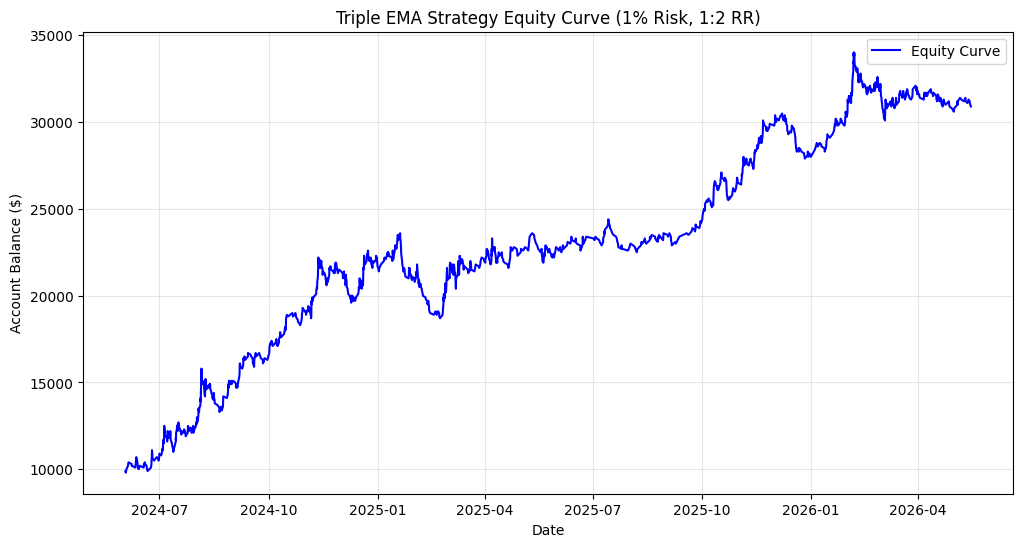

In [ ]:
# ============================================================
# 📈 STEP 5: PERFORMANCE ANALYSIS
# ============================================================
if not trades_df.empty:
    # Basic Metrics
    total_pnl = trades_df['PnL'].sum()
    winning_trades = trades_df[trades_df['PnL'] > 0]
    losing_trades = trades_df[trades_df['PnL'] < 0]

    win_rate = len(winning_trades) / len(trades_df) * 100
    gross_profit = winning_trades['PnL'].sum()
    gross_loss = abs(losing_trades['PnL'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else 0

    print("\n" + "="*40)
    print("📊 BACKTEST RESULTS (NO COSTS)")
    print("="*40)
    print(f"Initial Capital: ${INITIAL_CAPITAL:,.2f}")
    print(f"Final Capital:   ${INITIAL_CAPITAL + total_pnl:,.2f}")
    print(f"Net Profit:      ${total_pnl:,.2f}")
    print(f"Total Trades:    {len(trades_df)}")
    print(f"Win Rate:        {win_rate:.2f}%")
    print(f"Profit Factor:   {profit_factor:.2f}")
    print("="*40)

    # Plot Equity Curve
    trades_df['Cumulative_PnL'] = trades_df['PnL'].cumsum()
    equity_curve = INITIAL_CAPITAL + trades_df['Cumulative_PnL']

    plt.figure(figsize=(12, 6))
    plt.plot(trades_df['Exit_Date'], equity_curve, label='Equity Curve', color='blue')
    plt.title('Triple EMA Strategy Equity Curve (1% Risk, 1:2 RR)')
    plt.xlabel('Date')
    plt.ylabel('Account Balance ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ No trades were executed. Check your signal logic or data range.")

In [ ]:
 #Cell 9: The "Prop Firm Reality" Simulation
#Why this code?
#We are re-running the engine with exact prop firm costs.
#Entry Price Adjustment: We enter at Open + Spread (for buys) or Open - Spread (for sells). This simulates starting the trade immediately in the negative.
#Commission Deduction: We subtract 0.06% of the total position value from every trade's PnL.
#Slippage: We add a random penalty to simulate execution delay.

In [ ]:
# ============================================================
# 💸 STEP 6: PROP FIRM REALITY CHECK (EXACT COSTS)
# ============================================================
print("💸 Applying Prop Firm Costs: Comm 0.06%, Spread 0.03%, Slip 0.02%...")

# Cost Parameters (Based on PropFirmMatch Data)
COMMISSION_PCT = 0.0006      # 0.03% per side * 2 = 0.06% round turn
SPREAD_PCT = 0.0003          # 0.03% Spread (Realistic for BTC)
SLIPPAGE_PCT = 0.0002        # 0.02% Average Slippage

trades_prop = []
in_trade = False
trade_type = None
entry_price = 0.0
entry_date = None
sl_price = 0.0
tp_price = 0.0
position_size = 0.0

for i in range(1, len(df)):
    current_row = df.iloc[i]
    prev_row = df.iloc[i-1]

    current_date = current_row['Datetime']
    current_open = current_row['Open']
    current_high = current_row['High']
    current_low = current_row['Low']

    # --- CHECK EXIT CONDITIONS ---
    if in_trade:
        exit_reason = None
        exit_price = 0.0

        if trade_type == 'BUY':
            if current_low <= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_high >= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        elif trade_type == 'SELL':
            if current_high >= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_low <= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        if exit_reason:
            # Calculate Gross PnL (based on clean entry/exit prices)
            gross_pnl = (exit_price - entry_price) * position_size if trade_type == 'BUY' else (entry_price - exit_price) * position_size

            # Apply Costs
            # 1. Commission: 0.06% of Total Position Value (Entry Price * Size)
            cost_commission = (entry_price * position_size) * COMMISSION_PCT

            # 2. Slippage: Randomized between 0 and 0.04% (avg 0.02%)
            slip_factor = np.random.uniform(0, SLIPPAGE_PCT * 2)
            cost_slippage = (entry_price * position_size) * slip_factor

            # Total Net PnL
            net_pnl = gross_pnl - cost_commission - cost_slippage

            trades_prop.append({
                'Entry_Date': entry_date,
                'Exit_Date': current_date,
                'Type': trade_type,
                'Entry_Price': entry_price,
                'Exit_Price': exit_price,
                'Position_Size': position_size,
                'Gross_PnL': gross_pnl,
                'Costs': cost_commission + cost_slippage,
                'Net_PnL': net_pnl,
                'Reason': exit_reason
            })
            in_trade = False
            trade_type = None

    # --- CHECK ENTRY CONDITIONS (With Spread) ---
    if not in_trade:
        if prev_row['Signal_Buy']:
            in_trade = True
            trade_type = 'BUY'

            # Apply Spread: You buy slightly higher than market open
            entry_price = current_open * (1 + SPREAD_PCT)

            entry_date = current_date
            # SL/TP are calculated from the ACTUAL entry price (including spread)
            sl_price = entry_price * 0.99
            tp_price = entry_price * 1.02

            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

        elif prev_row['Signal_Sell']:
            in_trade = True
            trade_type = 'SELL'

            # Apply Spread: You sell slightly lower than market open
            entry_price = current_open * (1 - SPREAD_PCT)

            entry_date = current_date
            sl_price = entry_price * 1.01
            tp_price = entry_price * 0.98

            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

# Convert to DataFrame
prop_df = pd.DataFrame(trades_prop)
print(f"✅ Prop Firm Simulation Complete. Total Trades: {len(prop_df)}")

💸 Applying Prop Firm Costs: Comm 0.06%, Spread 0.03%, Slip 0.02%...
✅ Prop Firm Simulation Complete. Total Trades: 1739



📊 PROP FIRM REALITY CHECK (BTC 1:5 Lev, 0.06% Comm)
Metric                    | Ideal (No Costs) | Prop Firm (Real)
------------------------------------------------------------
Net Profit                | $20,900.00      | $-906.19       
Win Rate                  | 37.39         % | 35.83         %
Total Fees Paid           | $0.00           | $13,906.19     
Return on Capital         | 209.00        % | -9.06         %


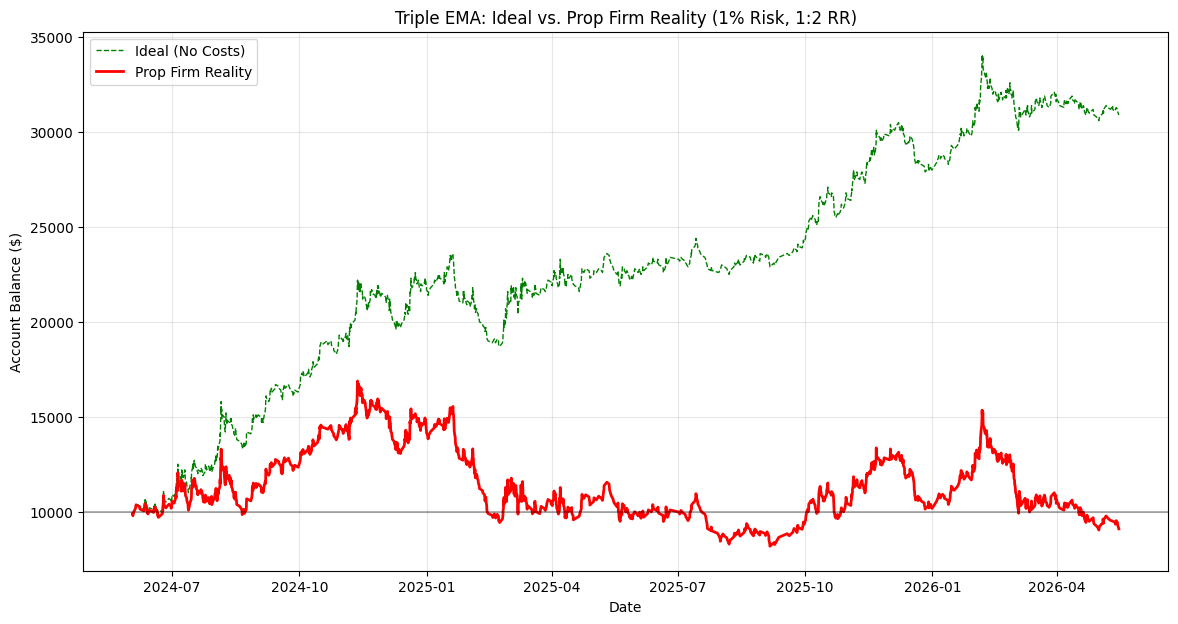

In [ ]:
# ============================================================
# 📊 STEP 7: FINAL PROP FIRM ANALYSIS
# ============================================================
if not prop_df.empty:
    total_net_pnl = prop_df['Net_PnL'].sum()
    total_costs = prop_df['Costs'].sum()
    win_rate_prop = len(prop_df[prop_df['Net_PnL'] > 0]) / len(prop_df) * 100

    # Previous No-Cost Stats
    total_gross_pnl = trades_df['PnL'].sum()
    win_rate_no_cost = len(trades_df[trades_df['PnL'] > 0]) / len(trades_df) * 100

    print("\n" + "="*60)
    print("📊 PROP FIRM REALITY CHECK (BTC 1:5 Lev, 0.06% Comm)")
    print("="*60)
    print(f"{'Metric':<25} | {'Ideal (No Costs)':<15} | {'Prop Firm (Real)':<15}")
    print("-" * 60)
    print(f"{'Net Profit':<25} | ${total_gross_pnl:<14,.2f} | ${total_net_pnl:<14,.2f}")
    print(f"{'Win Rate':<25} | {win_rate_no_cost:<14.2f}% | {win_rate_prop:<14.2f}%")
    print(f"{'Total Fees Paid':<25} | {'$0.00':<15} | ${total_costs:<14,.2f}")
    print(f"{'Return on Capital':<25} | {(total_gross_pnl/10000)*100:<14.2f}% | {(total_net_pnl/10000)*100:<14.2f}%")
    print("="*60)

    # Plot Comparison
    trades_df['Cumulative_Gross'] = trades_df['PnL'].cumsum()
    prop_df['Cumulative_Net'] = prop_df['Net_PnL'].cumsum()

    plt.figure(figsize=(14, 7))
    plt.plot(trades_df['Exit_Date'], INITIAL_CAPITAL + trades_df['Cumulative_Gross'], label='Ideal (No Costs)', color='green', linestyle='--', linewidth=1)
    plt.plot(prop_df['Exit_Date'], INITIAL_CAPITAL + prop_df['Cumulative_Net'], label='Prop Firm Reality', color='red', linewidth=2)

    plt.axhline(y=INITIAL_CAPITAL, color='black', linestyle='-', alpha=0.3)
    plt.title('Triple EMA: Ideal vs. Prop Firm Reality (1% Risk, 1:2 RR)')
    plt.xlabel('Date')
    plt.ylabel('Account Balance ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ No trades executed.")